### 4.1.1 데이터 주도학습

사람 -> 규칙성을 찾는다, 직관과 경험을 단서로 시행착오를 거듭하며 일을 진행

기계학습 -> 수집한 데이터로부터 패턴을 찾으려고 시도

5를 예를 들면 5의 데이터들을 보고 숨은 규칙성을 찾아내기에는 너무 어려움

이를 인식하는 알고리즘을 설계하는 대신, 데이터를 잘 활용해서 해결하고 싶어진다.

이를 특징을 추출하고 이 특징의 패턴을 기계학습 기술로 학습하는 방법이 존재

## 4.2 손실 함수

신경망은 하나의 지표를 기준으로 최적의 매개변수 값을 탐색하는데, 이 지표를 `Loss Function(Error Function)`이라 함

MSE (Mean Squared Error)

$E = \dfrac{1}{2}\sum\limits_k{(y_k - t_k)^2}$

In [ ]:
import numpy as np


def MSE(y, t):

    return 0.5 * np.sum((y-t)**2)

In [ ]:
t = np.array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0])

y = np.array([0.1, 0.05, 0.6, 0.0, 0.05, 0.1, 0.0, 0.1, 0.0, 0.0])
print(MSE(y, t))

y = np.array([0.1, 0.05, 0.1, 0.0, 0.05, 0.1, 0.0, 0.6, 0.0, 0.0])
print(MSE(y, t))

0.09750000000000003
0.5975


첫 번째 예의 손실 함수 쪽 출력이 작으며 정답 레이블과의 오차도 작은 것을 알 수 있습니다.

평균 제곱 오차를 기준으로는 첫 번째 추정 결과가 정답에 더 가까운 것을 확인할 수 있습니다.

### 4.2.2 교차 엔트로피 오차

$ E = -\sum\limits_{k}t_k log(y_k) $

$y_k$는 신경망의 출력, $t_k$는 정답 레이블

또 $t_k$는 정답에 해당하는 인덱스의 원소만 1이고 나머지는 0(one-hot coding)

실질적으로 $t_k$가 1일때만 계산하는 식이 된다.

<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:10: SyntaxWarning: invalid escape sequence '\l'
C:\Users\jshkr\AppData\Local\Temp\ipykernel_4600\2613224592.py:10: SyntaxWarning: invalid escape sequence '\l'
  plt.legend(["$y = \log{x}$"])
C:\Users\jshkr\AppData\Local\Temp\ipykernel_4600\2613224592.py:5: RuntimeWarning: divide by zero encountered in log
  y = np.log(x)


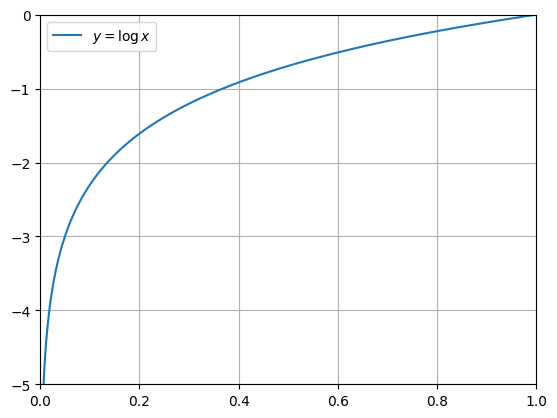

In [9]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0.0, 1.0, 1000)
y = np.log(x)
plt.plot(x, y)
plt.xlim(0, 1)
plt.ylim(-5, 0)
plt.grid()
plt.legend(["$y = \log{x}$"])
plt.show()

교차 엔트로피 오차를 구현해보자

아주 작은 0인  $\delta = 10^{-7}$를 넣어서 -inf를 방지

In [15]:
def cross_entropy_error(y, t):
    delta = 1e-7
    return -np.sum(t*np.log(y+delta))

In [ ]:
t = [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
y = [0.1, 0.05, 0.6, 0.0, 0.05, 0.1, 0.0, 0.1, 0.0, 0.0]

print(cross_entropy_error(np.array(y), np.array(t)))

y = [0.1, 0.05, 0.1, 0.0, 0.05, 0.1, 0.0, 0.1, 0.0, 0.0]
print(cross_entropy_error(np.array(y), np.array(t)))

0.510825457099338
2.302584092994546


### 4.2.3 미니배치 학습

기계학습 -> 훈련 데이터를 사용해 학습.

이제 훈련 데이터 모두에 대한 손실함수의 합을 구하는 방법은?

\begin{align}
E = -\dfrac{1}{N} \large\sum\limits_{n}\sum\limits_{k}t_{nk}logy_nk
\end{align}

이때 데이터가 N개라면 $t_{nk}$는 $n$번째 데이터의 $k$번째 값을 의미합니다.
($y_{nt}$는 신경망의 출력, $t_{nk}$는 정답 레이블)

이렇게 평균을 사용하면 훈련 데이터 개수와 관계없이 언제든 통일된 지표를 얻을 수 있습니다.

* 데이터가 너무 많을 때는 일부만 골라 학습을 수행 -> 이를 미니배치라고 함

훈련 데이터에서 지정한 수의 데이터를 무작위로 골라내는 코드를 작성

In [ ]:
from dataset.mnist import load_mnist
import numpy as np
import sys
import os
sys.path.append(os.pardir)

(x_train, t_train), (x_test, t_test) = \
    load_mnist(normalize=True, one_hot_label=True)

print(x_train.shape)
print(t_train.shape)

(60000, 784)
(60000, 10)


784 = 28 * 28이므로 28*28 이미지 데이터임을 알 수 있다. \
정답 레이블은 10줄, 0 ~ 9의 인식 \

**np.random.choice()** 로 지정한 범위의 수 중에서 무작위로 원하는 개수만 꺼낼 수 있다. \
손실 함수도 이 미니배치를 통해서 계산

In [ ]:
np.random.choice(60000, 10)

array([ 4573,  3657, 52147, 58591, 48070, 19353, 16088, 33631, 24975,
       35815])

In [ ]:
"""
(배치용) 교차 엔트로피 오차 구현하기
"""


def cross_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)

    batch_size = y.shape[0]
    return -np.sum(t*np.log(y+1e-7)) / batch_size

In [ ]:
"""
(배치용) 교차 엔트로피 오차 구현하기
- 정답 레이블이 one-hot encoding이 아니라 '2', '7'의 경우

- np.log(y[np.aragne(batch_size),t]) 설명

0 ~ (batch_size - 1)까지의 배열을 생성.
t에는 지금 [2,7,0,9,4]와 같이 저장되어 있으므로
y[np.arange(batch_size), t]는 각 데이터의 정답 레이블에 해당하는 신경망의 출력을 추출
여기서는 y[0,2], y[1,7], ... 을 생성
"""


def cross_entropy_error_num(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)

    batch_size = y.shape[0]
    return -np.sum(np.log(y[np.arange(batch_size), t] + 1e-7)) / batch_size

f의 차분을 계산하는 방법

$x$를 중심으로 그 전후의 차분을 계산한다는 의미에서 **중심차분** 혹은 **중앙차분**이라고 한다

한편 $(x+h)$와 $x$의 차분은 **전방차분**이라고 함.

### 4.3.2 수치미분의 예

$y = 0.01x^2 + 0.1x$ 를 그려보자

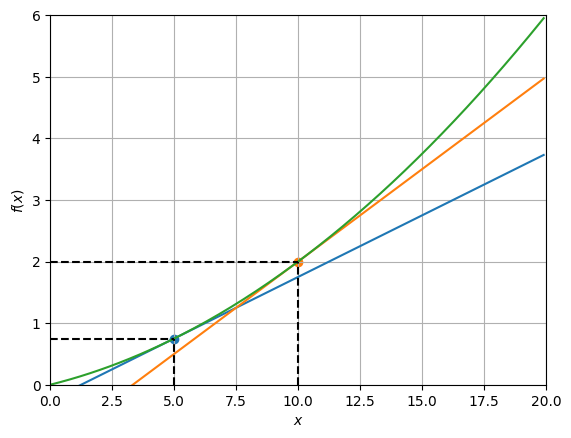

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the function


def function_1(x):
    return 0.01 * x ** 2 + 0.1 * x

# Define the numerical differentiation function


def numerical_diff(f, x):
    h = 1e-4  # Small step
    return (f(x + h) - f(x - h)) / (2 * h)


# Set up the data
x = np.arange(0.0, 20.0, 0.1)
y = function_1(x)

# Calculate the derivatives at specific points
x1, x2 = 5, 10
y1, y2 = function_1(x1), function_1(x2)
diff1 = numerical_diff(function_1, x1)
diff2 = numerical_diff(function_1, x2)

# Plot the tangent lines at x = 5 and x = 10
plt.plot(x, diff1 * (x - x1) + y1, label="Tangent at x=5")
plt.plot(x, diff2 * (x - x2) + y2, label="Tangent at x=10")

# Plot the original function
plt.plot(x, y, label="$f(x) = 0.01x^2 + 0.1x$")
plt.ylabel("$f(x)$")
plt.xlabel("$x$")

# Add perpendicular lines (foot of perpendicular)
plt.vlines(x1, 0, y1, color='black', linestyle='--',
           label=f"Perpendicular at x={x1}")
plt.vlines(x2, 0, y2, color='black', linestyle='--',
           label=f"Perpendicular at x={x2}")
plt.hlines(y1, 0, x1, color='black', linestyle='--')
plt.hlines(y2, 0, x2, color='black', linestyle='--')

plt.scatter(x1, y1)
plt.scatter(x2, y2)

# Display settings
plt.xlim(0, 20)
plt.ylim(0, 6)
plt.grid()
plt.show()

In [ ]:
print(numerical_diff(function_1, 5))
print(numerical_diff(function_1, 10))

0.1999999999990898
0.2999999999986347


### 4.3.3 편미분

$f(x_0, x_1) = x_0^2 + x_1^2$

In [45]:
def function_2(x):
    return np.sum(x**2)

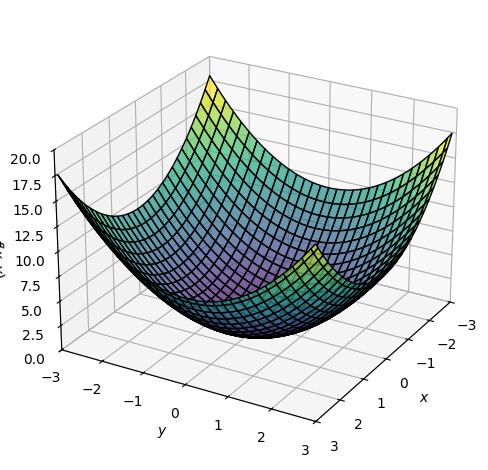

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define the function with a single array input


def function_2(x):
    return x[0]**2 + x[1]**2  # 예시 함수


# Set up the grid
x = np.arange(-3.0, 3.0, 0.1)
y = np.arange(-3.0, 3.0, 0.1)
X, Y = np.meshgrid(x, y)

# Combine X and Y into a single array for function input
Z = function_2([X, Y])

# Plot using 3D surface plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap="viridis", edgecolor="k", alpha=0.7)

# Set axis limits
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_zlim(0, 20)

# Adjust viewpoint
ax.view_init(elev=25, azim=30)  # Adjust viewing angle

# Labels and title
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_zlabel("$f(x, y)$")

# Show plot
plt.tight_layout()
plt.show()

문제 1 : $x_0 = 3, x_1 = 4$일 때, $x_0$에 대한 편미분 $\dfrac{\partial f}{\partial x_0}$를 구하여라

In [67]:
def function_tmp1(x0):
    return x0**2 + 4.0**2.0

In [68]:
numerical_diff(function_tmp1, 3.0)

6.00000000000378

### 4.4 기울기

$x_0$ 와 $x_1$의 편미분을 동시에 계산하려면

$\Big( \dfrac{\partial f}{\partial x_0}, \dfrac{\partial f}{\partial x_1} \Big)$

이것을 **gradient**라고 한다


In [76]:
def numerical_gradient(f, x):
    h = 1e-4
    grad = np.zeros_like(x)  # x와 shape가 같은 0 행렬

    for idx in range(x.size):
        tmp_val = x[idx]
        x[idx] = tmp_val + h
        fxh1 = f(x)

        x[idx] = tmp_val - h
        fxh2 = f(x)

        grad[idx] = (fxh1 - fxh2) / (2*h)
        x[idx] = tmp_val

    return grad

In [80]:
print(numerical_gradient(function_2, np.array([3.0, 4.0])))
print(numerical_gradient(function_2, np.array([0.0, 2.0])))
print(numerical_gradient(function_2, np.array([3.0, 0.0])))

[6. 8.]
[0. 4.]
[6. 0.]


C:\Users\jshkr\AppData\Local\Temp\ipykernel_4632\1221206550.py:76: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


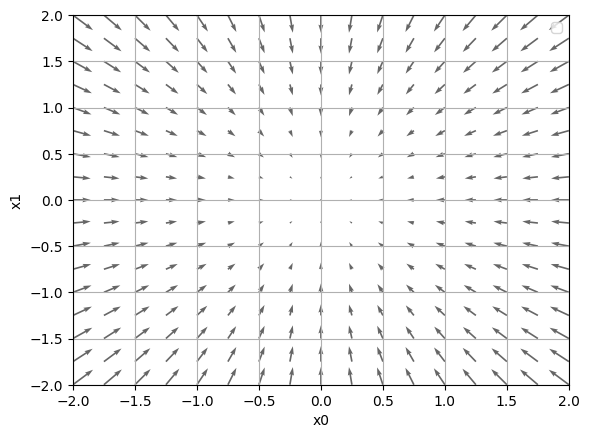

In [4]:
# coding: utf-8
# cf.http://d.hatena.ne.jp/white_wheels/20100327/p3
import numpy as np
import matplotlib.pylab as plt
from mpl_toolkits.mplot3d import Axes3D


def _numerical_gradient_no_batch(f, x):
    h = 1e-4  # 0.0001
    grad = np.zeros_like(x)  # x와 형상이 같은 배열을 생성

    for idx in range(x.size):
        tmp_val = x[idx]

        # f(x+h) 계산
        x[idx] = float(tmp_val) + h
        fxh1 = f(x)

        # f(x-h) 계산
        x[idx] = tmp_val - h
        fxh2 = f(x)

        grad[idx] = (fxh1 - fxh2) / (2*h)
        x[idx] = tmp_val  # 값 복원

    return grad


def numerical_gradient(f, X):
    if X.ndim == 1:
        return _numerical_gradient_no_batch(f, X)
    else:
        grad = np.zeros_like(X)

        for idx, x in enumerate(X):
            grad[idx] = _numerical_gradient_no_batch(f, x)

        return grad


def function_2(x):
    if x.ndim == 1:
        return np.sum(x**2)
    else:
        return np.sum(x**2, axis=1)


def tangent_line(f, x):
    d = numerical_gradient(f, x)
    print(d)
    y = f(x) - d*x
    return lambda t: d*t + y


"""
    if __name__ == __main__
"""

x0 = np.arange(-2, 2.5, 0.25)
x1 = np.arange(-2, 2.5, 0.25)
X, Y = np.meshgrid(x0, x1)

X = X.flatten()
Y = Y.flatten()

grad = numerical_gradient(function_2, np.array([X, Y]))

plt.figure()
# ,headwidth=10,scale=40,color="#444444")
plt.quiver(X, Y, -grad[0], -grad[1],  angles="xy", color="#666666")
plt.xlim([-2, 2])
plt.ylim([-2, 2])
plt.xlabel('x0')
plt.ylabel('x1')
plt.grid()
plt.legend()
plt.draw()